# Intro

This notebook describes how I set up my luxury Jupyter environment inside Home Assistant. I started with [Franck Nijhof's JupyterLab Application/Add-on.](https://github.com/hassio-addons/app-jupyterlab)

**<u>Some environment setup things that are very helpful:</u>**

- Go to the config page of the JupyterLab Add-on/App and instead of putting individual init commands into the config page, just put one init command that points to a custom bash script of your choice which is stored in the `/config/notebooks` directory.  You can edit this file easily through Jupyter or other HA editors and install many Python and operating system packages.  My custom bash script `/homeassistant/notebooks/custom_jlab_init_script` is in a section down below.<br>

- Some notebooks need to be able to ssh into the HAOS host.  How to set this up using "dropbear" is descibed in the [Home Assistant Developer Debugging documentation](https://developers.home-assistant.io/docs/operating-system/debugging/).  When you create your ssh keys, you can save them under your `/config/notebooks` directory so that they will persist. You can also use your custom bash init script to copy your ssh keys from their saved location under `/config/notebooks` into `/root/.ssh` so that they are available during every run of Jupyter.<br>


- You need to manually take control of your JupyterLab configuration by first [generating](https://stackoverflow.com/a/50750181) a config file, then moving that config file under your `/config/notebooks` directory, and then using your custom bash init script to link your saved config file from `/config/notebooks` to `/root/.jupyter/jupyter_lab_config.py`.  I added some custom config at the end of my `jupyter_lab_config.py` file, and I've pasted a snippet of that file into a section down below.

<br><br>
**<u>Only show widgets, not Markdown documentation:</u>** 

Many of my notebooks are designed to be displayed as Voila dashboards which <u>only show</u> the final chart/widget and <u>nothing else</u> (no other cells, including markdown cells).  This requires Voila to be configured to ignore all cells which are tagged "hide" as per the [Voila documentation](https://voila.readthedocs.io/en/stable/customize.html#hiding-output-and-code-cells-based-on-cell-tags). Unfortunately, there is a [Github issue](https://github.com/voila-dashboards/voila/issues/171#issuecomment-1870920037) which mentions that **this does not work**.  

The simplest workaround is to use the [**prelaunch_hook**](https://voila.readthedocs.io/en/stable/customize.html#customizing-voila-with-hooks) functionality to create a function that does the same thing.  This function is placed at the end of your `jupyter_lab_config.py` file.  Refer to the section below (*Snippet from jupyter_lab_config.py*) for how to implement this.

Another thing that is helpful is to pip install the **jupyterlab_celltagsclasses** package, which converts cell tags into DOM classes.  Then you can set up a custom CSS file as described in the [Jupyter docs](https://jupyterlab.readthedocs.io/en/latest/user/interface_customization.html#applying-custom-css) which will render your "hide" cells differently; this lets you quickly and easily see what has been tagged with "hide".  [Here](https://github.com/parmentelat/jupyterlab-celltagsclasses/blob/main/style/base.css) are CSS examples.  My own `custom.css` file is below.  It makes my "hide" cells look like this:

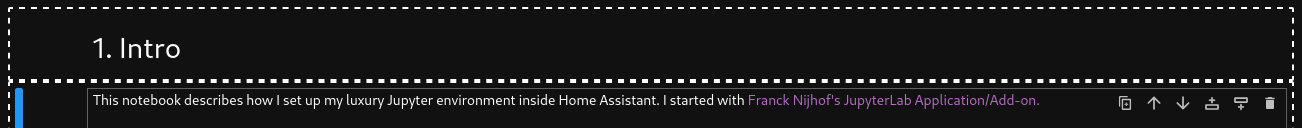

*(I have found that you might need to click and unclick the tag button a couple of times before the CSS styling for that tag gets applied to the cell.)*

<br><br>
**<u>Integrate into dashboards</u>**

Even better, if you use a [Home Assistant WebPage Card](https://www.home-assistant.io/dashboards/iframe/), you can display this bare Voila dashboard as if it were a native Home Assistant chart.  To do this, I use a URL like the following, where **XXX.YYY.XXX.YYY** is the IP address of my Home Assistant instance on my network:
```bash
http://XXX.YYY.XXX.YYY:8123/api/hassio_ingress/D_bhYaGUX2iR9mvImr11nqNvwxNAOPHvS6grkX7Ycfs/voila/render/docker_disk_space.ipynb?
```

**<u>NOTE:</u>**  You must turn on [idle kernel culling](https://voila.readthedocs.io/en/stable/customize.html#cull-idle-kernels) in your `/root/.jupyter/jupyter_lab_config.py` file, otherwise every time you visit the dashboard that contains a WebPage Card pointing to this Voila notebook, **ANOTHER** kernel will be started, which will eventually eat up all your RAM.



## /homeassistant/notebooks/custom_jlab_init_script
```bash
#!/bin/bash

# There were some issues regarding node.js keys being upgraded at the source,
# making it impossible to install node packages in this container because
# it had obsolete keys.  I manually downloaded the correct key for node.js
# and then saved it in /config/notebooks/nodesource.gpg.  The lines below
# copy this key into a couple of different areas so that node.js installs
# and upgrades can work properly again.
rm -f /usr/share/keyrings/nodesource.gpg
cp /config/notebooks/nodesource.gpg /usr/share/keyrings/nodesource.gpg
cp /config/notebooks/nodesource.gpg /etc/apt/keyrings/nodesource.gpg

# After generating some ssh keys within this container, and copying them
# to the HAOS bare metal root environment using ha i
mkdir /root/.ssh
cp /config/notebooks/root_ssh_config /root/.ssh/config
cp /config/notebooks/root_ssh_keys/* /root/.ssh

mkdir -p /root/.jupyter/custom
ln -s /config/notebooks/jupyter_config_custom_css/custom.css /root/.jupyter/custom/custom.css
ln -s /config/notebooks/jupyter_lab_config.py /root/.jupyter/

apt update
apt install -y python3-dev
apt install -y sshpass
apt install -y procps
apt install -y less

#pip install -U jupyterlab

#pip install jupyterlab_scenes
pip install papermill
pip install jupyter-resource-usage
pip install ipydatagrid
pip install jupyterlab_execute_time
pip install voila
pip install pandasql
pip install jupyterlab-skip-traceback
pip install hass_pyscript_kernel
pip install ollama
pip install paramiko
pip install docker
pip install plumbum
pip install rpyc
pip install anywidget
pip install plotly==5.24.1
pip install humanize
pip install tabulate
pip install jupyterlab_celltagsclasses

#jupyter lab build

jupyter pyscript install

cat > /usr/local/share/jupyter/kernels/pyscript/pyscript.conf <<END
[homeassistant]
hass_host = homeassistant
hass_url = http://supervisor/core/
hass_token = $SUPERVISOR_TOKEN
END

mkdir -p /config/notebooks/pyscript
ln -sf /config/pyscript /config/notebooks/pyscript/config-pyscript
curl https://raw.githubusercontent.com/craigbarratt/hass-pyscript-jupyter/master/pyscript_tutorial.ipynb -o /config/notebooks/pyscript/pyscript_tutorial.ipynb
```

## Snippet from jupyter_lab_config.py
```python

# This lets you add your own CSS styling through the
# /root/.jupyter/custom/custom.css file that you can create.
c.LabApp.custom_css = True

# The following allows Voila dashboards to be embedded
c.VoilaConfiguration.tornado_settings = {"headers":{"Content-Security-Policy":"frame-ancestors *", "Access-Control-Allow-Origin":"*" }}

# This makes debugging possible because it avoids silent errors 
c.VoilaConfiguration.show_tracebacks = True

# This allows your dashboard to appear as you go, instead of only when all cells have finished executing.
# This enables custom informative splash screens
c.VoilaConfiguration.progressive_rendering = True

# The following does not work, even though the Voila documentation claims that it should work
# Instead, the function below can duplicate this functionality
c.VoilaConfiguration.TagRemovePreprocessor.remove_all_outputs_tags={"hide"}

# This is a function that just excludes cells which contain 'hide' as a tag
def prelaunch_hook_tag_filter_function(req, notebook, cwd):
    """Removes cells with the 'hide' tag"""
    new_cells = []
    
    for cell in notebook.cells:
        if 'tags' not in cell.get("metadata", {}):
            new_cells.append(cell)
            
        elif 'hide' not in cell.get("metadata", {}).get("tags", []):
            new_cells.append(cell)

    notebook.cells = new_cells
    return notebook

# This sets up the tag filter as a prelaunch hook for each notebook.
c.VoilaConfiguration.prelaunch_hook = prelaunch_hook_tag_filter_function

```

## /root/.jupyter/custom/custom.css
```css
.cell-tag-hide {
  border: 2.5px white dashed !important;
  /* background-color: green !important; */
  /* could be overridden if cell is active */
  /* background-color: yellow !important; */
}
```